# RAG Triad Evaludations
Apply the RAG Triad to assess the data agent's goal completion. Each step of a data agent's execution seeks to accomplish tasks which can be evaluated via the RAG triad:
- research can be evaluated using context relevance
- information synthesis can be evaluated with groundedness to assess response accuracy
- end-to-end relevance can be evaluated via answer relevance
These metrics are evaluated with an LLM judge.



In [1]:
import os
from dotenv import load_dotenv
import warnings

load_dotenv(override=True)
warnings.filterwarnings("ignore")

os.environ["TRULENS_OTEL_TRACING"] = "1"

In [2]:
from trulens.providers.openai import OpenAI

# Use GPT-4o for RAG Triad Evaluations
provider = OpenAI(model_engine="gpt-4o")

In [ ]:
# Groundness Feedback Function
import numpy as np
from trulens.core import Feedback
from trulens.core.feedback.selector import Selector
from trulens.otel.semconv.trace import SpanAttributes

# Define a groundedness feedback function
f_groundedness = (
    Feedback(
        provider.groundedness_measure_with_cot_reasons, 
        name="Groundedness"
    )
    .on({
            "source": Selector(
                span_type=SpanAttributes.SpanType.RETRIEVAL,
                span_attribute=SpanAttributes.RETRIEVAL.RETRIEVED_CONTEXTS,
                collect_list=True
            )
        }
    )
    .on_output()
)

In [4]:
# Question/answer relevance between overall question and answer.
f_answer_relevance = (
    Feedback(provider.relevance_with_cot_reasons, name="Answer Relevance")
    .on_input()
    .on_output()
)

In [5]:
# Context relevance between question and each context chunk.
f_context_relevance = (
    Feedback(provider.context_relevance_with_cot_reasons, 
             ame="Context Relevance")
    .on({
            "question": Selector(
                span_type=SpanAttributes.SpanType.RETRIEVAL,
                span_attribute=SpanAttributes.RETRIEVAL.QUERY_TEXT,
            )
        }
    )
    .on({
            "context": Selector(
                span_type=SpanAttributes.SpanType.RETRIEVAL,
                span_attribute=SpanAttributes.RETRIEVAL.RETRIEVED_CONTEXTS,
                collect_list=False
            )
        }
    )
    .aggregate(np.mean)
)

## 4.2 Create TruLens session for logging

The database will store OpenTelemetry traces and evaluations (also in opentelemetry format) as events.

In [6]:
from trulens.core.session import TruSession
from trulens.core.database.connector.default import DefaultDBConnector

# Initialize connector with SQLite database one folder back
connector = DefaultDBConnector(database_url="sqlite:///default.sqlite")

# Create TruSession with the custom connector
session = TruSession(connector=connector)
session.reset_database()

🦑 Initialized with db url sqlite:///default.sqlite .
🛑 Secret keys may be written to the database. See the `database_redact_keys` option of `TruSession` to prevent this.


Updating app_name and app_version in apps table: 0it [00:00, ?it/s]
Updating app_id in records table: 0it [00:00, ?it/s]
Updating app_json in apps table: 0it [00:00, ?it/s]


✅ experimental Feature.OTEL_TRACING enabled.
🔒 experimental Feature.OTEL_TRACING is enabled and cannot be changed.


Updating app_name and app_version in apps table: 0it [00:00, ?it/s]
Updating app_id in records table: 0it [00:00, ?it/s]
Updating app_json in apps table: 0it [00:00, ?it/s]


## 4.3 Add custom instrumentation to methods that produce intermediate context

In [7]:
from helper import cortex_agent, State
from trulens.core.otel.instrument import instrument
from langchain.schema import HumanMessage
from langgraph.graph import END
from langgraph.types import Command
from typing import Literal

In [8]:
@instrument(
    span_type=SpanAttributes.SpanType.RETRIEVAL,
    attributes=lambda ret, exception, *args, **kwargs: {
        SpanAttributes.RETRIEVAL.QUERY_TEXT: args[0].get("agent_query") if args[0].get("agent_query") else None,
        SpanAttributes.RETRIEVAL.RETRIEVED_CONTEXTS: [
            ret.update["messages"][-1].content
        ] if hasattr(ret, "update") else "No tool call",
    },
)
def cortex_agents_research_node(
    state: State,
) -> Command[Literal["executor"]]:
    query = state.get("agent_query", state.get("user_query", ""))
    # Call the tool with the string query
    agent_response = cortex_agent.invoke({"messages":query})
    # Compose a message content string with all results new HumanMessage with the result
    new_message = HumanMessage(content=agent_response['messages'][-1].content, name="cortex_researcher")
    # Append to the message history
    goto = "executor"
    return Command(
        update={"messages": [new_message]},
        goto=goto,
    )

In [ ]:
from helper import web_search_agent

@instrument(
    span_type=SpanAttributes.SpanType.RETRIEVAL,
    attributes=lambda ret, exception, *args, **kwargs: {
        SpanAttributes.RETRIEVAL.QUERY_TEXT: args[0].get("agent_query") if args[0].get("agent_query") else None,
        SpanAttributes.RETRIEVAL.RETRIEVED_CONTEXTS: [
            ret.update["messages"][-1].content
        ] if hasattr(ret, "update") else "No tool call",
    },
)
def web_research_node(
    state: State,
) -> Command[Literal["executor"]]:
    agent_query = state.get("agent_query")
    result = web_search_agent.invoke({"messages":agent_query})
    goto = "executor"
    # wrap in a human message, as not all providers allow
    # AI message at the last position of the input messages list
    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content, name="web_researcher"
    )
    return Command(
        update={
            # share internal message history of research agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )

## 4.4 Build the graph with added instrumentation

In [9]:
from langgraph.graph import START, StateGraph
from helper import State, planner_node, executor_node, cortex_agents_research_node, web_research_node, chart_node, chart_summary_node, synthesizer_node

workflow = StateGraph(State)
workflow.add_node("planner", planner_node)
workflow.add_node("executor", executor_node)
workflow.add_node("web_researcher", web_research_node)
workflow.add_node("cortex_researcher", cortex_agents_research_node)
workflow.add_node("chart_generator", chart_node)
workflow.add_node("chart_summarizer", chart_summary_node)
workflow.add_node("synthesizer", synthesizer_node)

workflow.add_edge(START, "planner")

graph = workflow.compile()

## 4.5 Register the agent with TruLens

In [10]:
from trulens.apps.langgraph import TruGraph

tru_recorder = TruGraph(
    graph,
    app_name="Sales Data Agent",
    app_version="L4: Base",
    feedbacks=[
        f_answer_relevance,
        f_context_relevance,
        f_groundedness,
    ],
)

instrumenting <class 'langgraph.graph.state.StateGraph'> for base <class 'langgraph.graph.state.StateGraph'>
instrumenting <class 'langgraph.graph.state.CompiledStateGraph'> for base <class 'langgraph.graph.state.CompiledStateGraph'>
	instrumenting invoke
	instrumenting ainvoke
	instrumenting stream
	instrumenting astream
instrumenting <class 'langgraph.graph.state.CompiledStateGraph'> for base <class 'langgraph.pregel.main.Pregel'>
	instrumenting invoke
	instrumenting ainvoke
	instrumenting stream
	instrumenting astream


WARNI [trulens.feedback.computer] feedback_name=Groundedness, record=df4fffd5-bc4d-4d46-85e1-4ee995762956, span_group=None had an error during computation:
Endpoint OpenAIEndpoint request failed 1 time(s): 
	Error code: 429 - {'error': {'message': 'exceeded quota for this month'}}
WARNI [trulens.feedback.computer] feedback_name=Groundedness, record=df4fffd5-bc4d-4d46-85e1-4ee995762956, span_group=None had an error during computation:
Endpoint OpenAIEndpoint request failed 1 time(s): 
	Error code: 429 - {'error': {'message': 'exceeded quota for this month'}}
WARNI [trulens.feedback.computer] feedback_name=Groundedness, record=df4fffd5-bc4d-4d46-85e1-4ee995762956, span_group=None had an error during computation:
Endpoint OpenAIEndpoint request failed 1 time(s): 
	Error code: 429 - {'error': {'message': 'exceeded quota for this month'}}


## 4.6 Record agent usage

Query: What are our top 3 client deals? Chart the deal value for each.


WARNI [langchain_experimental.utilities.python] Python REPL can execute arbitrary code. Use with caution.


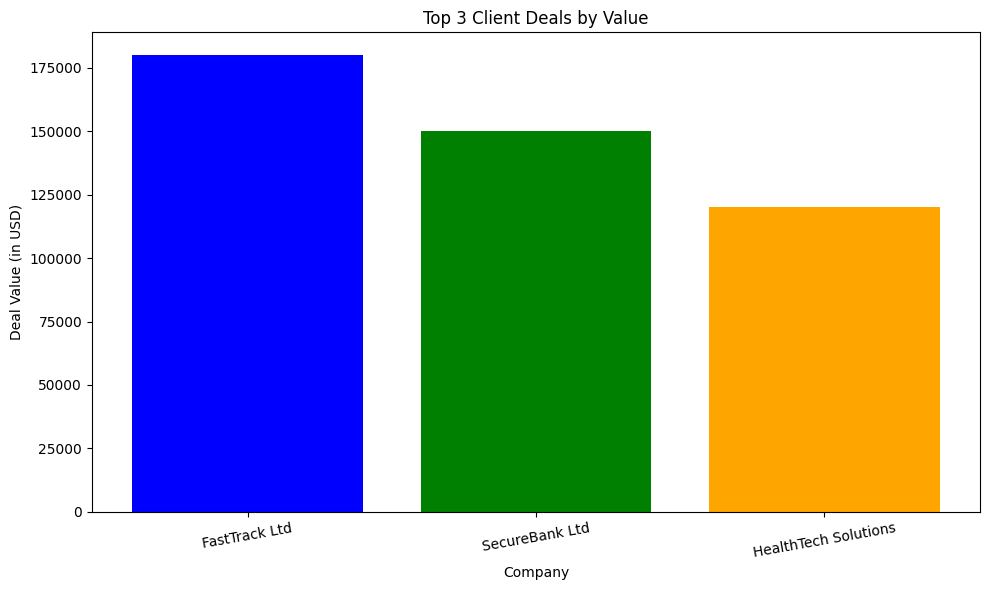

Chart summarizer answer: The top three client deals are FastTrack Ltd with a deal value of $180,000, SecureBank Ltd with a deal value of $150,000, and HealthTech Solutions with a deal value of $120,000.
--------------------------------


<Figure size 640x480 with 0 Axes>

In [11]:
from langchain.schema import HumanMessage

with tru_recorder as recording:
    query = "What are our top 3 client deals? Chart the deal value for each."
    print(f"Query: {query}")
    state = {
                "messages": [HumanMessage(content=query)],
                "user_query": query,
                "enabled_agents": ["cortex_researcher", "web_researcher", 
                                   "chart_generator", "chart_summarizer", 
                                   "synthesizer"],
            }
    graph.invoke(state)

    print("--------------------------------")

In [ ]:
with tru_recorder as recording:
    query = "Identify our pending deals, research if they may be experiencing regulatory changes, and using the meeting notes for each customer, provide a new value proposition for each given the regulatory changes."
    print(f"Query: {query}")
    state = {
                "messages": [HumanMessage(content=query)],
                "user_query": query,
                "enabled_agents": ["cortex_researcher", "web_researcher", 
                                   "chart_generator", "chart_summarizer", 
                                   "synthesizer"],
            }
    graph.invoke(state)

    print("--------------------------------")

Query: Identify our pending deals, research if they may be experiencing regulatory changes, and using the meeting notes for each customer, provide a new value proposition for each given the regulatory changes.


In [13]:
with tru_recorder as recording:
    query = "Identify our largest client deal, then find important topics in the meeting notes with that company, and find a news article related to the important topics discussed."
    print(f"Query: {query}")
    state = {
                "messages": [HumanMessage(content=query)],
                "user_query": query,
                "enabled_agents": ["cortex_researcher", "web_researcher", 
                                   "chart_generator", "chart_summarizer", 
                                   "synthesizer"],
            }
    graph.invoke(state)

    print("--------------------------------")

Synthesizer answer: - **Largest Client Deal:** The largest client deal is with "FastTrack Ltd" valued at $180,000. This deal was closed on February 12, 2024, by sales representative Sarah Johnson, focusing on the "Premium Security" product line.

- **Important Topics in Meeting Notes:** Meeting notes with "FastTrack Ltd" highlight key topics such as cybersecurity, advanced threat detection, integration with existing systems, and customer service improvements.

- **Related News Article:** Currently, I don't have direct access to external news databases to find a relevant article. However, based on the important topics discussed, you might consider searching for news articles on recent advancements or incidents in cybersecurity, or specific developments related to advanced threat detection systems.

Citations: [...]
--------------------------------


## 4.7 Launch the TruLens dashboard

In [14]:
from trulens.dashboard import run_dashboard
import os
str_port = 8001
_ = run_dashboard(port=str_port)
print(os.environ['DLAI_LOCAL_URL'].format(port=str_port))

Starting dashboard ...


Accordion(children=(VBox(children=(VBox(children=(Label(value='STDOUT'), Output())), VBox(children=(Label(valu…

Dashboard started at http://localhost:8001 .
https://s172-29-5-132p8001.lab-aws-production.deeplearning.ai/
